In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [76]:
df = pd.read_csv(r'C:\Users\ADMIN\Desktop\Jupyter folder/Downloads/gender_classification.csv')
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [77]:
df.head(5)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [5]:
print('Rows and Columns of the Dataset : \n',df.shape)

Rows and Columns of the Dataset : 
 (5001, 8)


In [6]:
print('Missing value in the Dataset : \n',df.isnull().sum())

Missing value in the Dataset : 
 long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64


In [78]:
df_dup = df.duplicated().sum()
print('Number of duplicate value in the Dataset : ',df_dup)

Number of duplicate value in the Dataset :  1768


In [79]:
df.drop_duplicates(inplace = True)
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4986,1,11.7,6.1,1,1,0,1,Male
4990,1,12.6,5.7,0,0,1,0,Female
4992,1,14.1,7.0,1,1,1,1,Male
4993,1,11.6,5.9,0,0,0,1,Female


In [80]:
# Check outliers
Q1 = df['long_hair'].quantile(0.25)
Q3 = df['long_hair'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['long_hair'] > lower)|(df['long_hair'] < upper)]
print('Number of Outliers in long hair : ',outliers.shape[0])

Number of Outliers in long hair :  574


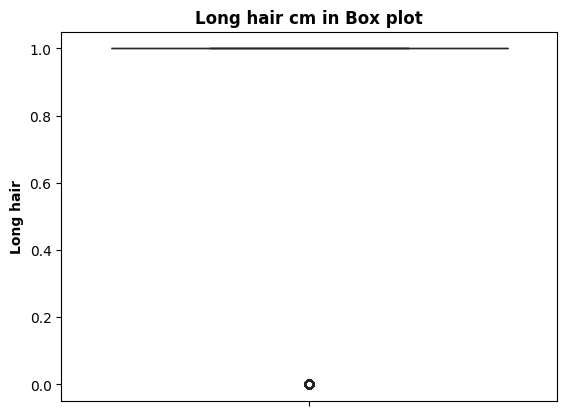

In [81]:
sns.boxplot(data=df['long_hair'], color='green')
plt.ylabel('Long hair',fontweight='bold')
plt.title('Long hair cm in Box plot',fontweight='bold')
plt.show()

In [84]:
# Encode gender (Male=1, Female=0)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [85]:
x = df.drop('gender',axis=1)
y = df['gender']
x
print(x.shape)

(3233, 7)


In [86]:
print(y)

0       1
1       0
2       1
3       1
4       0
       ..
4986    1
4990    0
4992    1
4993    0
4995    1
Name: gender, Length: 3233, dtype: int64


In [87]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.5, random_state=52)

In [88]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [92]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
# Evaluate the Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_predict = model.predict(x_test)
print('Accuracy : ',accuracy_score(y_test,y_predict))
print('\n')
print('Confusion matrix : \n',confusion_matrix(y_test,y_predict))
print('\n')
print('Classification report : ',classification_report(y_test, y_predict))

Accuracy :  0.9486703772418058


Confusion matrix : 
 [[714  47]
 [ 36 820]]


Classification report :                precision    recall  f1-score   support

      Female       0.95      0.94      0.95       761
        Male       0.95      0.96      0.95       856

    accuracy                           0.95      1617
   macro avg       0.95      0.95      0.95      1617
weighted avg       0.95      0.95      0.95      1617



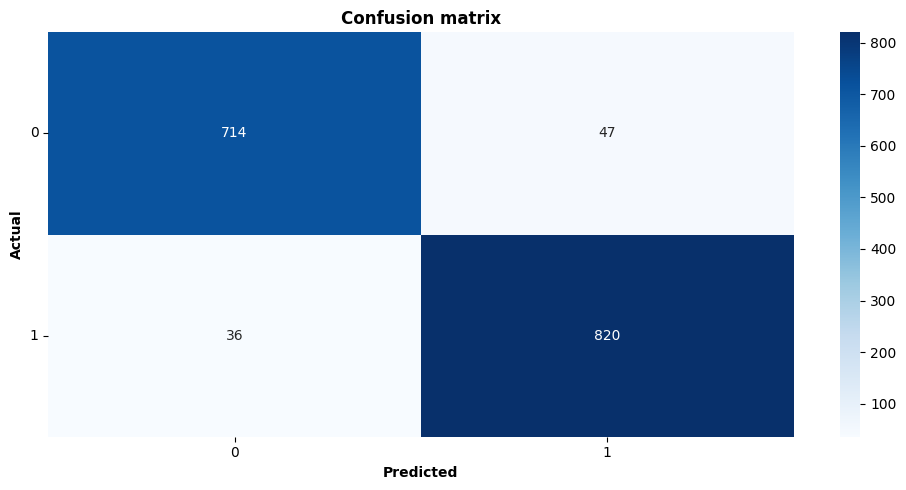

In [66]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(10,5))
sns.heatmap(data=cm, xticklabels=['0','1'], yticklabels=['0','1'], fmt='d', annot=True, cmap='Blues')
plt.xlabel('Predicted',fontweight='bold')
plt.ylabel('Actual',fontweight='bold')
plt.yticks(rotation=0)
plt.title('Confusion matrix',fontweight='bold')
plt.tight_layout()
plt.show()

In [95]:
sample = [[1,11.8, 6.1, 1, 0, 1, 1]]
prediction = model.predict(sample)
print('Prediction : ','No long'if prediction[0] == 1 else 'Having long hair')

Prediction :  No long


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [96]:
prediction = model.predict(x_test)
for i, pred in enumerate(prediction):
    print(f'Row {i}, Prediction : ','No long hair' if pred == 1 else 'Having long hair')

Row 0, Prediction :  Having long hair
Row 1, Prediction :  Having long hair
Row 2, Prediction :  No long hair
Row 3, Prediction :  No long hair
Row 4, Prediction :  No long hair
Row 5, Prediction :  Having long hair
Row 6, Prediction :  No long hair
Row 7, Prediction :  Having long hair
Row 8, Prediction :  Having long hair
Row 9, Prediction :  Having long hair
Row 10, Prediction :  No long hair
Row 11, Prediction :  Having long hair
Row 12, Prediction :  Having long hair
Row 13, Prediction :  Having long hair
Row 14, Prediction :  Having long hair
Row 15, Prediction :  Having long hair
Row 16, Prediction :  No long hair
Row 17, Prediction :  Having long hair
Row 18, Prediction :  No long hair
Row 19, Prediction :  No long hair
Row 20, Prediction :  Having long hair
Row 21, Prediction :  Having long hair
Row 22, Prediction :  No long hair
Row 23, Prediction :  Having long hair
Row 24, Prediction :  Having long hair
Row 25, Prediction :  Having long hair
Row 26, Prediction :  No long ha

In [98]:
row = x_test.iloc[5].values
prediction = model.predict([row])
for i, pred in enumerate(prediction):
    print(f'Row {i}, Prediction : ','No long hair' if pred == 1 else 'Having long hair')

Row 0, Prediction :  Having long hair


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [93]:
new_data = [[0, 13.5, 6.2, 1, 1, 0, 1]]
new_data_df = pd.DataFrame(new_data, columns=x.columns)
log_result = model.predict(new_data_df)[0]
rf_result = rf_model.predict(new_data_df)[0]
print('Logistic Regression : ',le.inverse_transform([log_result])[0])
print('Random Forest : ',le.inverse_transform([rf_result])[0])

Logistic Regression :  Male
Random Forest :  Male
